<a href="https://colab.research.google.com/github/BoKna031/GoogleColabFunProjects/blob/develop/Digimon_Story_Time_Stranger_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Imports
import os
import shutil
import requests
import pandas as pd

In [23]:
# Hyperparameters

LOAD_DATA_FROM_GITHUB = True
UPDATE_DATA_ON_GITHUB = False

# GitHub repo constants

REPO_ZIP_URL = "https://github.com/BoKna031/GoogleColabFunProjects/archive/refs/heads/develop.zip"
REPO_FOLDER = os.path.join("GoogleColabFunProjects-develop", "Digimon_Story_Time_Stranger_EDA")
REPO_DATA_FOLDER = os.path.join(REPO_FOLDER, "data")
MEMBERS_TO_EXTRACT = [REPO_DATA_FOLDER]

DATA_FOLDER_PATH = "data"
CSV_FOLDER_PATH = os.path.join(DATA_FOLDER_PATH, "csv")

#Scrape

DIGIMON_MAIN_PAGE_URL = "https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon"

# Loading Data from the GitHub Repository
To avoid unnecessary re-scraping of the official Digimon website, this section focuses on loading and updating
already stored data from a GitHub repository.

The repository serves as a centralized data source where previously scraped and processed datasets are stored.
By pulling data directly from GitHub, we ensure better reproducibility, faster execution, and reduced load on
the official website.

If the local data is missing or outdated, it can be updated from the repository instead of performing a full
scraping process again. This approach allows us to reuse existing datasets while still keeping them up to date
when needed.


In [ ]:
# main
'''
git clone --filter=blob:none --no-checkout https://github.com/user/repo.git
cd repo
git sparse-checkout init --cone
git sparse-checkout set GoogleColabFunProjects/Digimon_Story_Time_Stranger_EDA
git checkout
'''

'\ngit clone --filter=blob:none --no-checkout https://github.com/user/repo.git\ncd repo\ngit sparse-checkout init --cone\ngit sparse-checkout set GoogleColabFunProjects/Digimon_Story_Time_Stranger_EDA\ngit checkout\n'

In [3]:
def prepare_empty_directory(directory_path: str):
    """
    Ensures that the directory exists and is empty.
    If it exists, it will be cleared.
    """
    if os.path.exists(directory_path):
        shutil.rmtree(directory_path)

    os.makedirs(directory_path, exist_ok=True)

def download_repo_zip(repo_zip_url, output_zip_path):
  r = requests.get(repo_zip_url)
  with open(output_zip_path, "wb") as f:
      f.write(r.content)

def extract_selected_from_zip(zip_path, members_to_extract, target_dir):
    import zipfile
    import requests

    prepare_empty_directory(target_dir)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for member in zip_ref.namelist():
          if any(member.startswith(f"{m}/") or member == m for m in members_to_extract):
                zip_ref.extract(member, target_dir)

def move_folder_contents(src_folder, dst_folder):
    prepare_empty_directory(dst_folder)

    for item in os.listdir(src_folder):
        src = os.path.join(src_folder, item)
        dst = os.path.join(dst_folder, item)
        shutil.move(src, dst)


def fetch_data_from_repo(repo_zip_url, members_to_extract, output_folder_path):

    print(f"Fetching content from GitHub...")

    zip_path = "repo.zip"
    download_repo_zip(repo_zip_url, zip_path)

    unziped_dir_path = "unziped-data"
    extract_selected_from_zip(zip_path, members_to_extract, unziped_dir_path)

    prepare_empty_directory(output_folder_path)
    for item in os.listdir(unziped_dir_path):
      move_folder_contents(unziped_dir_path, output_folder_path)

    shutil.rmtree(unziped_dir_path)
    os.remove(zip_path)

    print(f"'{output_folder_path}' folder is ready and up-to-date!")

In [6]:
if (LOAD_DATA_FROM_GITHUB):
  fetch_data_from_repo(REPO_ZIP_URL, MEMBERS_TO_EXTRACT, DATA_FOLDER_PATH)

Fetching content from GitHub...
'data' folder is ready and up-to-date!


# Scraping the Basic Digimon Dataset
In this section, we will scrape the basic dataset of Digimon from the official source at `[All Digimon in Digimon Story Time Stranger](https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon)`.
The goal is to extract key information about each Digimon, such as their name, level, type, and other relevant attributes.

We will use Python libraries such as `requests` to fetch the webpage content, and `BeautifulSoup` from `bs4` to parse the HTML and extract structured data.

In [11]:
data_is_empty = not(os.path.exists(DATA_FOLDER_PATH) and len(os.listdir(DATA_FOLDER_PATH)))

should_scrape = UPDATE_DATA_ON_GITHUB == True or LOAD_DATA_FROM_GITHUB == False or data_is_empty
if should_scrape:
  !pip install requests beautifulsoup4 lxml pandas
  import requests
  from bs4 import BeautifulSoup

In [8]:
def scrape_page(url):
  headers = {
      "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
      "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
      "Accept-Language": "en-US,en;q=0.5",
      "Referer": "https://www.grindosaur.com/"
  }

  response = requests.get(url, headers=headers)
  print(response.status_code)

  return response


In [9]:
def parse_cell(td):
  img = td.find("img")
  link = td.find("a")

  return {
      "text": td.get_text(strip=True),
      "img_src": img["src"] if img else None,
      "img_alt": img.get("alt") if img else None,
      "img_title": img.get("title") if img else None,
      "link": link["href"] if link else None
  }

def parsing_main_page(soup):
  table = soup.find("table")
  thead = table.find("thead")
  header_row = thead.find_all("tr")[0]

  headers = [th.get_text(strip=True) for th in header_row.find_all("th")]

  tbody = table.find("tbody")
  rows = tbody.find_all("tr")

  parsed_rows = []

  for row in rows:
      tds = row.find_all("td")

      parsed_rows.append({
          "id": tds[0].get_text(strip=True),

          "icon_url": parse_cell(tds[1])["img_src"],

          "name": parse_cell(tds[2])["text"],
          "name_url": parse_cell(tds[2])["link"],

          "level": tds[3].get_text(strip=True),

          "attribute": parse_cell(tds[4])["text"],
          "attribute_icon": parse_cell(tds[4])["img_src"],

          "type": tds[5].get_text(strip=True),
          "personality": tds[6].get_text(strip=True),
      })

  return parsed_rows

In [15]:
# Parsing main page
if scrape_page:
  response = scrape_page(DIGIMON_MAIN_PAGE_URL)
  soup = BeautifulSoup(response.text, "lxml")

  parsed_rows = parsing_main_page(soup)
  scraped_df = pd.DataFrame(parsed_rows)
  os.makedirs(CSV_FOLDER_PATH, exist_ok=True)
  scraped_df.to_csv(f"{CSV_FOLDER_PATH}/digimon_main.csv", index=False)

200


In [24]:
df = pd.read_csv(f"{CSV_FOLDER_PATH}/digimon_main.csv")

In [19]:
from urllib.parse import urlparse

def download_unique_images(
    df,
    url_column: str,
    output_dir: str,
    headers: dict | None = None,
    timeout: int = 10,
    log_every: int = 50
) -> pd.DataFrame:
    """
    Downloads unique image URLs from a DataFrame column into a directory,
    and returns a DataFrame with columns:
      - 'url': original URL
      - 'local_path': path to downloaded image
    """

    prepare_empty_directory(output_dir)

    urls = df[url_column].dropna().unique().tolist()
    total = len(urls)
    print(f"📥 Downloading {total} unique images...\n")

    success = 0
    failed = 0
    records = []

    for idx, url in enumerate(urls, start=1):
        try:
            response = requests.get(url, headers=headers, timeout=timeout)
            response.raise_for_status()

            filename = os.path.basename(urlparse(url).path)
            file_path = os.path.join(output_dir, filename)

            with open(file_path, "wb") as f:
                f.write(response.content)

            success += 1
            records.append({"url": url, "local_path": file_path})

        except Exception:
            failed += 1
            records.append({"url": url, "local_path": None})

        # Progress logging
        if idx % log_every == 0 or idx == total:
            print(f"Progress: {idx}/{total} | ✔ {success} | ✖ {failed}")

    print("\n✅ Download completed.")

    return pd.DataFrame(records)


In [30]:
def save_dataframe_to_csv(df: pd.DataFrame, folder:str,  filename: str):
    """
    Save a Pandas DataFrame to a CSV file inside the 'csv/' folder.
    Creates the folder if it does not exist.

    Parameters:
    - df (pd.DataFrame): The DataFrame to save.
    - filename (str): Base name of the CSV file (without folder path).
    """
    # Ensure the folder exists
    os.makedirs(folder, exist_ok=True)

    file_path = os.path.join(folder, f"{filename}.csv")

    try:
        df.to_csv(file_path, index=False)
        print(f"DataFrame successfully saved to '{file_path}'.")
    except Exception as e:
        print(f"An error occurred while saving the DataFrame: {e}")


In [31]:
# Downloading Digimon icons
if (scrape_page):
  df_icon_paths = download_unique_images(
      df,
      url_column="icon_url",
      output_dir=f"{DATA_FOLDER_PATH}/icons",
      log_every=100
  )
  save_dataframe_to_csv(df_icon_paths, CSV_FOLDER_PATH, "digimon_icon_paths")


📥 Downloading 465 unique images...

Progress: 100/465 | ✔ 100 | ✖ 0
Progress: 200/465 | ✔ 200 | ✖ 0
Progress: 300/465 | ✔ 300 | ✖ 0
Progress: 400/465 | ✔ 400 | ✖ 0
Progress: 465/465 | ✔ 465 | ✖ 0

✅ Download completed.
DataFrame successfully saved to 'data/csv/digimon_icon_paths.csv'.


In [32]:
# Downloading attribute icons
if (scrape_page):
  df_attr_paths = download_unique_images(
      df,
      url_column="attribute_icon",
      output_dir=f"{DATA_FOLDER_PATH}/attributes"
  )
  save_dataframe_to_csv(df_attr_paths, CSV_FOLDER_PATH, "attributes_paths")

📥 Downloading 7 unique images...

Progress: 7/7 | ✔ 7 | ✖ 0

✅ Download completed.
DataFrame successfully saved to 'data/csv/attributes_paths.csv'.


In [33]:
from IPython.display import Image, display

def display_images_from_df(df, image_columns, size=None):
    """
    Display images from specified columns of a DataFrame.

    Parameters:
    - df (pd.DataFrame): DataFrame containing image paths.
    - image_columns (list): List of column names that contain image paths.
    - size (int, optional): If given, sets both width and height of the images.
    """
    for i, row in df.iterrows():
        if size is not None:
            imgs = [Image(filename=row[col], width=size, height=size) for col in image_columns]
        else:
            imgs = [Image(filename=row[col]) for col in image_columns]
        display(*imgs)




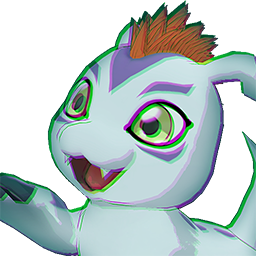

In [34]:
display_images_from_df(df_icon_paths.iloc[[22]], ['local_path'], size=100)

# TODO nastaviti odavde

ono sto je postignuto:


1.   Preuzeta osnovna tablea digimona (df)
2.   Preuzete slike ikonica digimona i sacuvane u folderu `icons`. Kreiran df `display_images_from_df` koji cuva za svaki url putanju gde je slika sacuvana
3.   Preuzete slike za svaki od mogucih atributa digimona i smestene u folder `attributes`. Takodje sacuvan df `df_attr_paths` koji cuva putanje do sacuvanih slika za svaki url.
4.   Sacuvani df u obliku csv-a unutar `csv` foldera


Planovi za nastavak: Kreirati df koji ce umesto url-a cuvati putanje do preuzetih slika za icon i attribute kolone





In [ ]:
def img_html(url, size=32):
    if not url:
        return ""
    return f'<img src="{url}" width="{size}" height="{size}"/>'


In [ ]:
df_images = df.copy()

df_images["icon"] = df_images["icon_url"].apply(img_html)
df_images["attr"] = df_images["attribute_icon"].apply(img_html)

df_images = df_images.drop(columns=["icon_url", "attribute_icon"])


In [ ]:
columns = ["id", "name", "icon", "attr", "type", "level", "personality", "name_url"]

In [ ]:
df_images = df_images[columns]

In [ ]:
df_images.head()

,id,name,icon,attr,type,level,personality,name_url
0,001,Kuramon,"<img src=""https://www.grindosaur.com/img/games...","<img src=""https://www.grindosaur.com/img/games...",Unidentified,In-Training I,Sly,https://www.grindosaur.com/en/games/digimon-st...
1,002,Choromon,"<img src=""https://www.grindosaur.com/img/games...","<img src=""https://www.grindosaur.com/img/games...",Machine,In-Training I,Friendly,https://www.grindosaur.com/en/games/digimon-st...
2,003,Dodomon,"<img src=""https://www.grindosaur.com/img/games...","<img src=""https://www.grindosaur.com/img/games...",Slime,In-Training I,Reckless,https://www.grindosaur.com/en/games/digimon-st...
3,004,Pabumon,"<img src=""https://www.grindosaur.com/img/games...","<img src=""https://www.grindosaur.com/img/games...",Slime,In-Training I,Tolerant,https://www.grindosaur.com/en/games/digimon-st...
4,005,Punimon,"<img src=""https://www.grindosaur.com/img/games...","<img src=""https://www.grindosaur.com/img/games...",Slime,In-Training I,Friendly,https://www.grindosaur.com/en/games/digimon-st...


In [ ]:
from IPython.display import display, HTML

def display_with_attribute_bg(df, attribute_bg="#444444"):
    """
    Display a DataFrame in Colab/Jupyter with a custom background color
    for the 'attribute' column.
    """
    # Pozicija kolone attribute u tabeli (1-based)
    attribute_idx = df.columns.get_loc('attr') + 2

    styles = f"""
    <style>
    table.dataframe td:nth-child({attribute_idx}) {{
        background-color: {attribute_bg};
    }}
    </style>
    """
    display(HTML(styles + df.to_html(escape=False)))


In [ ]:
display_with_attribute_bg(df_images[df_images["level"] == "Ultimate"].head(10))

,id,name,icon,attr,type,level,personality,name_url
192,193,Aegiochusmon,,,Deity,Ultimate,Friendly,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/aegiochusmon
193,194,Aegiochusmon: Green,,,Deity,Ultimate,Friendly,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/aegiochusmon-green
194,195,Aegiochusmon: Dark,,,Deity,Ultimate,Reckless,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/aegiochusmon-dark
195,196,Aegiochusmon: Blue,,,Deity,Ultimate,Sociable,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/aegiochusmon-blue
196,197,Aegiochusmon: Holy,,,Deity,Ultimate,Friendly,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/aegiochusmon-holy
197,198,MegaKabuterimon,,,Insectoid,Ultimate,Sly,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/megakabuterimon
198,199,Andromon,,,Android,Ultimate,Devoted,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/andromon
199,200,Wingdramon,,,Sky Dragon,Ultimate,Daring,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/wingdramon
200,201,AeroVeedramon,,,Holy Dragon,Ultimate,Zealous,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/aeroveedramon
201,202,ExTyrannomon,,,Puppet,Ultimate,Daring,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/extyrannomon


In [ ]:
!pip install networkx matplotlib


In [ ]:
import networkx as nx

# Napravi prazan graf
G = nx.DiGraph()  # DiGraph jer evolucije imaju smer

# 1️⃣ Dodajemo sve Digimone kao node sa svim atributima
for _, row in df_images.iterrows():
    G.add_node(
        row["name_url"],  # jedinstveni ID
        id=row["id"],
        name=row["name"],
        icon=row["icon"],
        attr=row["attr"],
        type=row["type"],
        level=row["level"],
        personality=row["personality"]
    )

print(f"✅ Created {len(G.nodes)} nodes in the graph")


✅ Created 465 nodes in the graph


In [ ]:
df["level"].dropna().unique().tolist()

['In-Training I',
 'In-Training II',
 'Rookie',
 'Champion',
 'Armor',
 'Hybrid',
 'Ultimate',
 'Mega',
 'Mega +']

In [ ]:
pd.set_option("display.max_colwidth", 500)
df_images[df_images["level"] == "In-Training I"]["name_url"].head(10)

,name_url
0,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/kuramon
1,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/choromon
2,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/dodomon
3,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/pabumon
4,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/punimon
5,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/botamon
6,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/poyomon


In [ ]:
def parse_evolves_table(name_url):
    """
    Parsira tabelu Digivolves sa stranice pojedinačnog Digimona.
    Vraća DataFrame sa kolonama 'name' i 'name_url'.
    """
    headers = {
        "User-Agent": "Mozilla/5.0"
    }
    response = requests.get(name_url, headers=headers)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "lxml")

    # 1️⃣ Nadji <h2 id="evolves-from">
    h2_tag = soup.find("h2", id="evolves-from")
    if not h2_tag:
        print(f"⚠️ No h2#evolves-from found for {name_url}")
        return pd.DataFrame(columns=["name", "name_url"])

    # 2️⃣ Prvi sibling div nakon h2 koji sadrzi <table>
    div_with_table = None
    for sibling in h2_tag.find_next_siblings():
        if sibling.name == "div" and sibling.find("table"):
            div_with_table = sibling
            break

    if not div_with_table:
        print(f"⚠️ No table found after h2#evolves-from for {name_url}")
        return pd.DataFrame(columns=["name", "name_url"])

    table = div_with_table.find("table")

    # 3️⃣ Parsiraj redove tabele
    rows = table.find("tbody").find_all("tr")

    data = []
    for row in rows:
        name_td = row.find_all("td")[1]  # druga kolona Name
        link_tag = name_td.find("a")
        name_text = name_td.get_text(strip=True)
        link_href = link_tag["href"] if link_tag else None

        data.append({
            "name": name_text,
            "name_url": link_href
        })

    df = pd.DataFrame(data)
    return df


In [ ]:
parse_evolves_table("https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/jupitermon")

,name,name_url
0,Aegiochusmon,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/aegiochusmon
1,Aegiochusmon: Holy,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/aegiochusmon-holy
2,Aegiochusmon: Blue,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/aegiochusmon-blue
3,Aegiochusmon: Green,https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/aegiochusmon-green


In [ ]:
import time

G.clear_edges()

for idx, row in df_images.iterrows():
    source_url = row["name_url"]

    try:
        df_evolves = parse_evolves_table(source_url)  # dobija name i name_url
        if df_evolves.empty:
            continue

        for _, evo_row in df_evolves.iterrows():
            target_url = evo_row["name_url"]

            # Dodaj bidirekcione veze
            # evaluate_to: source -> target
            G.add_edge(source_url, target_url, relation="evaluate_from")
            # evaluate_from: target -> source
            G.add_edge(target_url, source_url, relation="evaluate_to")

        if (idx + 1) % 50 == 0:
            print(f"Processed {idx + 1}/{len(df_images)} Digimons")

        # mala pauza da ne bi server blokirao zahteve
        time.sleep(0.1)

    except Exception as e:
        print(f"⚠️ Failed for {source_url} -> {e}")

⚠️ No h2#evolves-from found for https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/kuramon
⚠️ No h2#evolves-from found for https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/choromon
⚠️ No h2#evolves-from found for https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/dodomon
⚠️ No h2#evolves-from found for https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/pabumon
⚠️ No h2#evolves-from found for https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/punimon
⚠️ No h2#evolves-from found for https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/botamon
⚠️ No h2#evolves-from found for https://www.grindosaur.com/en/games/digimon-story-time-stranger/digimon/poyomon
Processed 10/465 Digimons
Processed 20/465 Digimons
Processed 30/465 Digimons
Processed 40/465 Digimons
Processed 50/465 Digimons
Processed 60/465 Digimons
Processed 70/465 Digimons
Processed 80/465 Digimons
Process

In [ ]:
import networkx as nx

# Sačuvaj u GraphML format
nx.write_graphml(G, "digimon_graph.graphml")

# Ili GEXF format (pogodno za Gephi)
nx.write_gexf(G, "digimon_graph.gexf")

print("✅ Graph saved to 'digimon_graph.graphml' and 'digimon_graph.gexf'")


✅ Graph saved to 'digimon_graph.graphml' and 'digimon_graph.gexf'


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_digimon_graph(G, edge_type="both", figsize=(15, 15), node_size=600, font_size=8, seed=42):
    """
    Prikazuje Digimon graf ili subgraf sa opcijom filtriranja edge-ova.

    Parametri:
    - G: NetworkX graf ili subgraph
    - edge_type: "both", "evaluate_to" ili "evaluate_from"
    - figsize: veličina figure (tuple)
    - node_size: veličina node-ova
    - font_size: veličina fonta za label-e
    - seed: za reproducibilni raspored

    """
    # 1️⃣ Filtriranje edge-ova po tipu
    if edge_type in ["evaluate_to", "evaluate_from"]:
        edges_to_draw = [(u, v) for u, v, d in G.edges(data=True) if d.get("relation") == edge_type]
    else:
        edges_to_draw = list(G.edges(data=True))

    # 2️⃣ Layout
    plt.figure(figsize=figsize)
    pos = nx.spring_layout(G, k=0.5, seed=seed)

    # 3️⃣ Boje node-ova po level-u
    level_colors = {
        "In-Training I": "lightblue",
        "Rookie": "skyblue",
        "Champion": "orange",
        "Ultimate": "red",
        "Mega": "purple",
        "Mega +": "darkviolet",
        "Armor": "green"
    }
    node_colors = [level_colors.get(G.nodes[n].get("level", ""), "grey") for n in G.nodes()]

    # 4️⃣ Labels
    labels = {n: G.nodes[n]["name"] for n in G.nodes()}

    # 5️⃣ Crtanje node-ova
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=font_size)

    # 6️⃣ Crtanje edge-ova
    if edges_to_draw:
        nx.draw_networkx_edges(
            G, pos,
            edgelist=[(u, v) for u, v, _ in edges_to_draw],
            arrowstyle='-|>', arrowsize=15,
            edge_color='black'
        )

    plt.title("Digimon Evolucioni Graf")
    plt.axis('off')
    plt.show()


In [ ]:
# Lista node-ova sa level-om 'Mega +' ili 'Mega'
selected_nodes = [
    n for n, attr in G.nodes(data=True)
    if attr.get("level") in ["Mega +", "Mega"]
]

print(f"Found {len(selected_nodes)} nodes with level 'Mega +' or 'Mega'")


Found 148 nodes with level 'Mega +' or 'Mega'


In [ ]:
G_sub = G.subgraph(selected_nodes).copy()

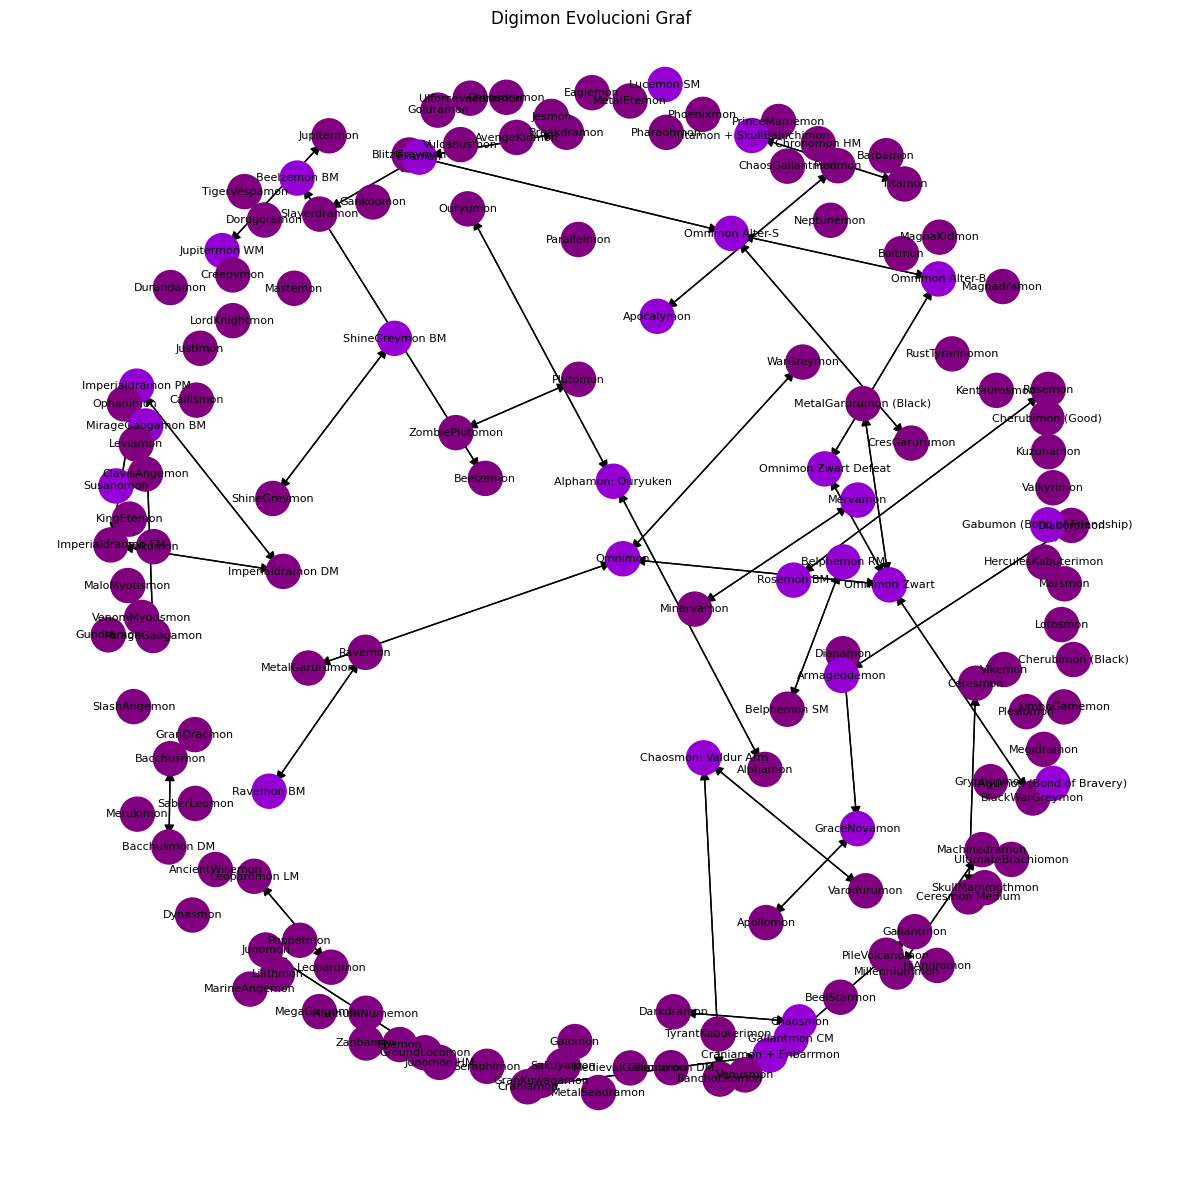

In [ ]:
plot_digimon_graph(G_sub, edge_type="both")


In [ ]:
df_images[df_images['name'] == 'aegiochusmon:_blue']

,id,name,icon,attr,type,level,personality,name_url
